In [166]:
!pip install astropy
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.constants as const
from astropy.io import fits
import scipy 
import urllib.request
import os 
from scipy import optimize

In [8]:
NGC2660_555_fits = "hst_10634_03_acs_wfc_f555w_j9dm03_drc.fits"
NGC2660_814_fits = "hst_10634_03_acs_wfc_f814w_j9dm03_drc.fits"
NGC2660_fits = "hst_10634_03_acs_wfc_total_j9dm03.fits"
NGC2660_fits_url = "https://hla.stsci.edu/cgi-bin/getdata.cgi?config=ops&dataset=hst_10634_03_acs_wfc_total_j9dm03"
NGC2660_555_fits_url = "https://hla.stsci.edu/cgi-bin/getdata.cgi?config=ops&download=1&dataset=hst_10634_03_acs_wfc_total_j9dm03&filename=hst_10634_03_acs_wfc_f555w_j9dm03_drc.fits"
NGC2660_814_fits_url = "https://hla.stsci.edu/cgi-bin/getdata.cgi?config=ops&download=1&dataset=hst_10634_03_acs_wfc_total_j9dm03&filename=hst_10634_03_acs_wfc_f814w_j9dm03_drc.fits"

if not os.path.exists(NGC2660_814_fits) & os.path.exists(NGC2660_555_fits):
        try:
            urllib.request.urlretrieve(NGC2660_814_fits_url, NGC2660_814_fits)
            print(f"Downloaded {NGC2660_814_fits}")
            urllib.request.urlretrieve(NGC2660_555_fits_url, NGC2660_555_fits)
            print(f"Downloaded {NGC2660_555_fits}")
        except Exception as e:
            print("Error Downloading File")
            NGC2660_555_fits = None
            NGC2660_814_fits = None

In [257]:
from matplotlib.colors import LogNorm

bands = [NGC2660_555_fits, NGC2660_814_fits]
image_data = []
for b in bands:
    with fits.open(b) as HDUList:
        image_data.append(HDUList[1].data) #reads the data from the SCI section of the fits file
        HDUList.close()
image_555, image_814 = image_data

sigma = 3
fwhm = 2.355 * sigma


[nan nan nan ... nan nan nan]


In [259]:
clipped_data_555 = image_555.copy()
for i in range(5):
    mean = np.nanmean(clipped_data_555)
    std = np.nanstd(clipped_data_555)
    mask = np.abs(clipped_data_555 - mean) <= 3 * std
    clipped_data = clipped_data_555[mask]
    background_mean_555 = np.mean(clipped_data)
import array



clipped_data_814 = image_814.copy()
for i in range(5):
    mean = np.nanmean(clipped_data_814)
    std = np.nanstd(clipped_data_814)
    mask = np.abs(clipped_data_814 - mean) <= 3 * std
    clipped_data = clipped_data_814[mask]
    background_mean_814 = np.mean(clipped_data)




#gaussian_PSF

In [261]:
subtracted_image_555 = image_555 - background_mean_555

plt.figure()
plt.imshow(subtracted_image, cmap='grey', origin = 'lower', norm=LogNorm())
plt.colorbar(norm=LogNorm())
plt.show()

fig, axes = plt.subplots()
axes.hist(.flatten(image_555.flatten(), bins=50, color='blue', range=(-.1, .75), alpha=.6)
axes.hist(subtracted_image_555.flatten(), bins=50, color='red', range=(-.1, .75), alpha=.6)

SyntaxError: invalid syntax (1902734641.py, line 9)

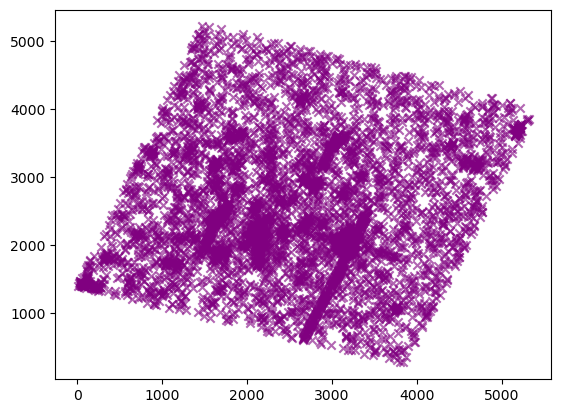

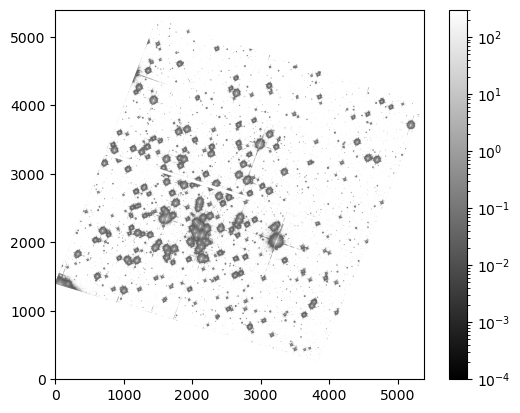

In [265]:
subtracted_image_555 = image_555 - background_mean_555
subtracted_image_814 = image_814 - background_mean_814
detection_threshold = 5 * background_mean_555

filter = int(np.ceil(fwhm))

local_max = scipy.ndimage.maximum_filter(subtracted_image, size=filter)

peaks = (subtracted_image == local_max) & (subtracted_image > detection_threshold)

detections_y, detections_x = np.where(peaks)

fig, axes = plt.subplots()

plt.figure()
plt.imshow(subtracted_image_555, cmap='grey', origin = 'lower', norm=LogNorm(vmin = .0001, vmax=300))
axes.scatter(detections_x, detections_y, color = 'purple', alpha =.6, marker='x')
plt.colorbar(norm=LogNorm(vmin = .0001, vmax=300))
plt.show()


#axes[2].hist(image_data.flatten(), bins=50, color='blue', range=(-.1, .75), alpha=.6)
#axes[2].hist(subtracted_image.flatten(), bins=50, color='red', range=(-.1, .75), alpha=.6)

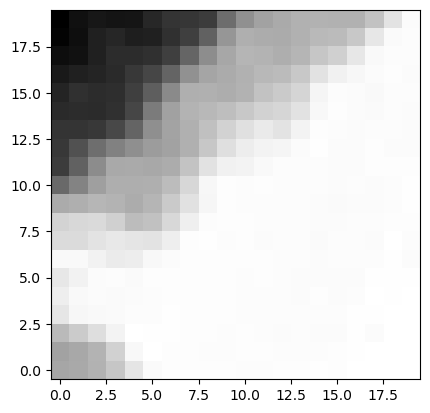

In [177]:
class Star:
    """One star is the coordinates of the center of a star on the image"""
    
    def __init__(self, row, col, name=""):
        self.row = row
        self.col = col
        self.name = name

    def get_row_col(self):
        return (self.row, self.col)

    def value_at(self, image):
        return image[self.row, self.col]

    def cutout(self, image, half_size=8):
        nrows, ncols = image.shape
        r_start = self.row - half_size
        r_end = self.row + half_size + 1
        c_start = self.col - half_size + 1
        c_end = self.col + half_size + 1
        if r_start < 0:
            r_start = 0
        if c_start < 0: 
            c_start = 0
        if r_end > nrows:
            r_end = nrows
        if c_end > ncols:
            c_end = ncols
        return image[r_start:r_end, c_start:c_end]


stars = [
    Star(1311, 1231, "1"),
    Star(544, 3297, "2"),
    Star(2910, 4128, "3"),
    Star(4462, 1557, "4"),
    Star(1657, 2605, "5"),
    Star(4064, 1437, "6"),
    Star(2160, 690, "7"),
    Star(4531, 1714, "8"),
    Star(2010, 3225, "9"),
    Star(2710, 1710, "10"),
    Star(4531, 1713, "11"),
    Star(4168, 2647, "12"),
    Star(3565, 3130, "13"),
    Star(3203, 1623, "14")
]


(272,)
[8.5, 8.0, 1.0, np.float32(208.57176), np.float32(0.963423)]
popt [  6.7037054    7.16857014   1.5489453  245.88465407   0.96342301]
(272,)
[8.5, 8.0, 1.0, np.float32(3.2142127), np.float32(-0.021720383)]
popt [ 6.71441128  8.38846631  0.94379466  3.40133761 -0.02172038]
(272,)
[8.5, 8.0, 1.0, np.float32(9.808505), np.float32(-0.0152230635)]
popt [ 7.2192659   8.40688428  0.91804069 10.89186266 -0.01522306]
(272,)
[8.5, 8.0, 1.0, np.float32(9.026221), np.float32(-0.013094347)]
popt [ 7.47219987  7.66851843  0.95287149  9.75878616 -0.01309435]
(272,)
[8.5, 8.0, 1.0, np.float32(27.383919), np.float32(0.024545956)]
popt [6.52921342e+00 7.76909035e+00 9.98514542e-01 3.07986861e+01
 2.45459564e-02]
(272,)
[8.5, 8.0, 1.0, np.float32(162.70038), np.float32(38.748566)]
popt [  6.49168405   5.83880456   4.15066744 216.15411147  38.74856567]
(272,)
[8.5, 8.0, 1.0, np.float32(211.63033), np.float32(9.806332)]
popt [ 10.86701275   9.1794791    3.73123221 213.76122342   9.80633163]
(272,)
[8

C:\Users\voide\AppData\Local\Temp\ipykernel_12368\2777709091.py:42: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(1, 3, figsize=(15, 5))


popt [ 10.87284337   8.65561014   4.60284977 235.91176588  35.84752655]
(272,)
[8.5, 8.0, 1.0, np.float32(112.44133), np.float32(0.32906562)]
popt [  6.48907943   7.83249658   0.98467194 111.15506938   0.32906562]
(272,)
[8.5, 8.0, 1.0, np.float32(6.4153595), np.float32(233.33575)]
popt [  7.68371353   7.85425083  10.         283.98053247 233.33575439]
(272,)
[8.5, 8.0, 1.0, np.float32(206.98013), np.float32(15.991493)]
popt [  7.4866513    8.50338063   3.3510431  251.85700124  15.99149323]
(272,)
[8.5, 8.0, 1.0, np.float32(112.44133), np.float32(0.32906562)]
popt [  7.48914417   7.83251133   0.98430032 111.22975701   0.32906562]
(272,)
[8.5, 8.0, 1.0, np.float32(75.45949), np.float32(131.77322)]
popt [  4.65219154   7.67465614   6.12335974 227.44762489 131.77322388]
(272,)
[8.5, 8.0, 1.0, np.float32(132.0642), np.float32(77.24373)]
popt [  8.66279916   8.71987246   4.81115424 225.29592828  77.24372864]
(272,)
[8.5, 8.0, 1.0, np.float32(66.27254), np.float32(140.39412)]
popt [  8.40716

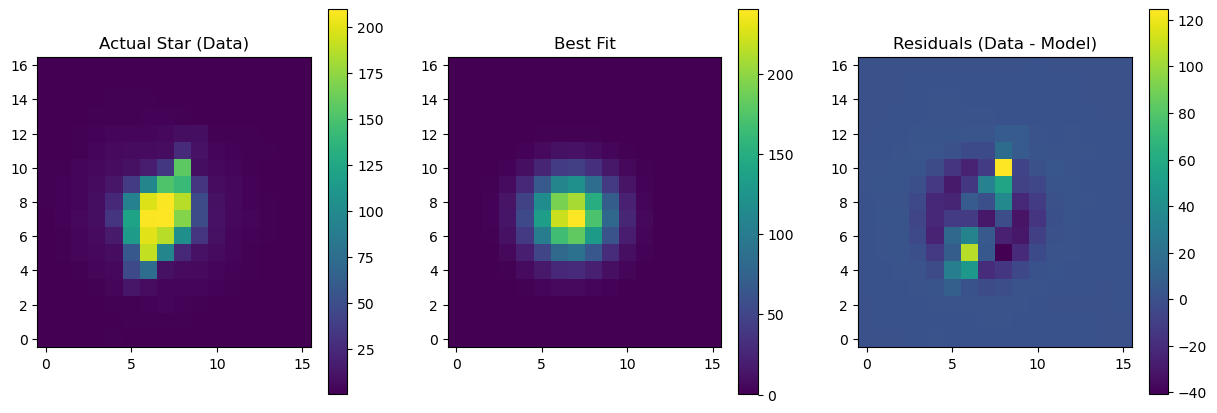

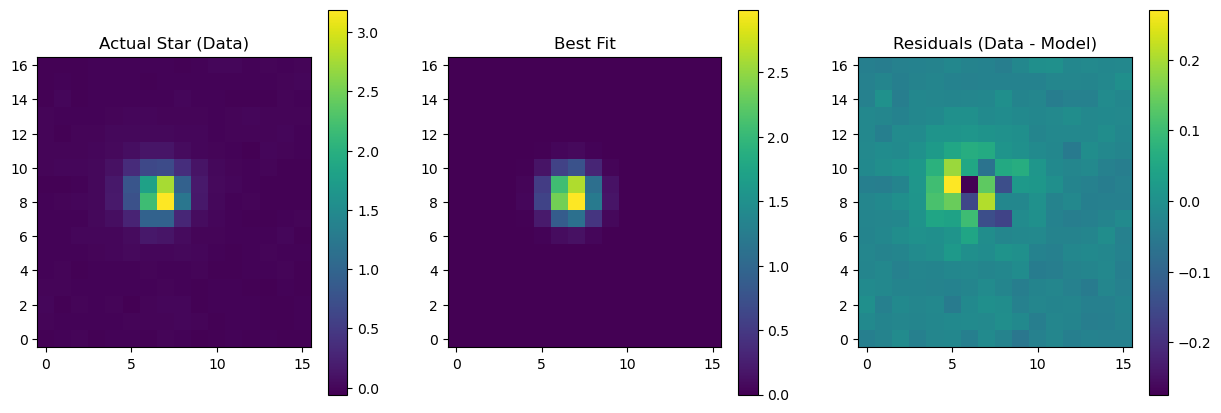

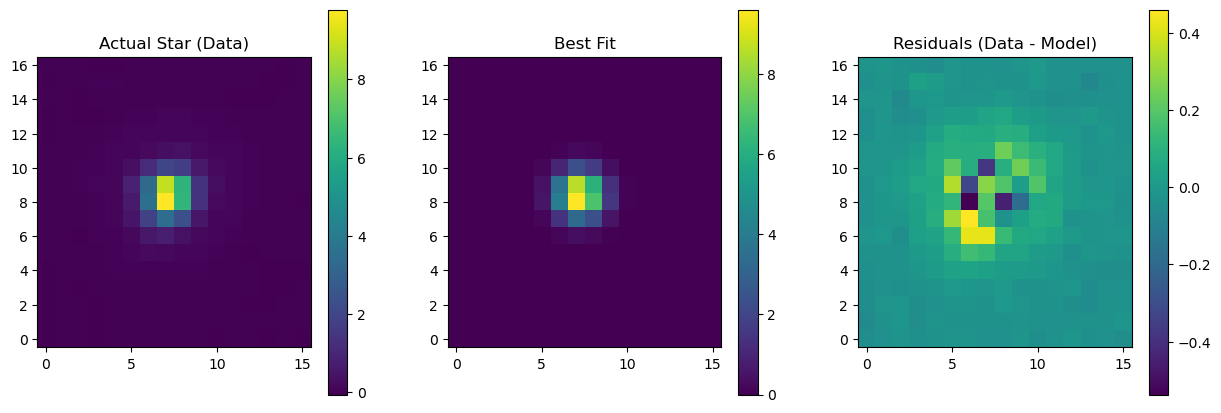

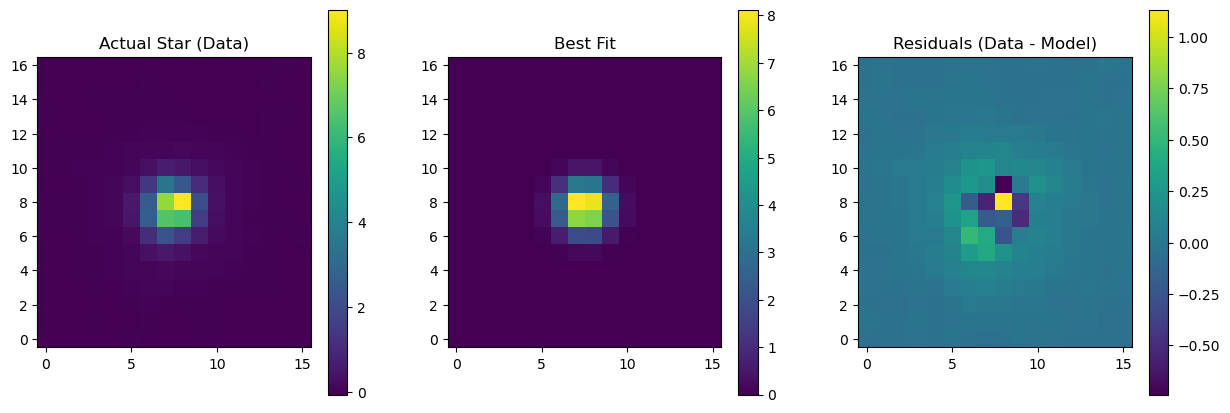

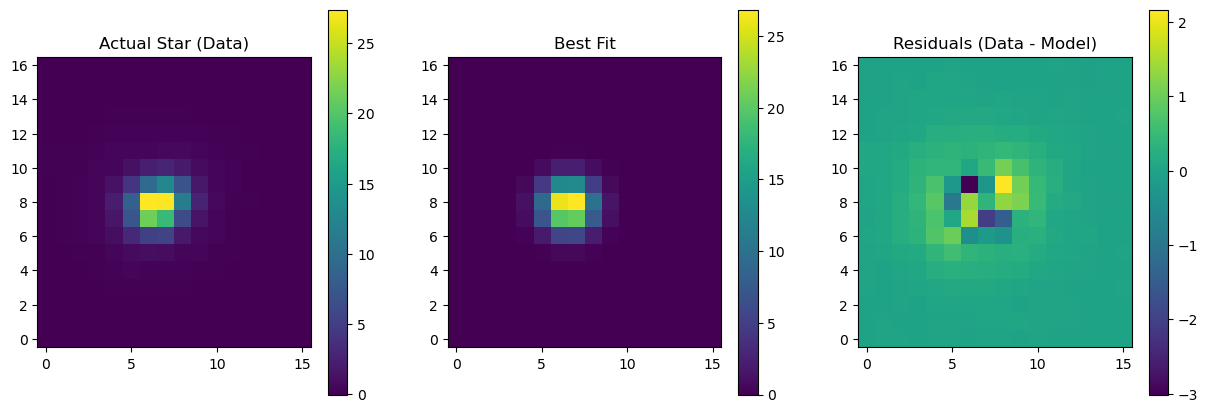

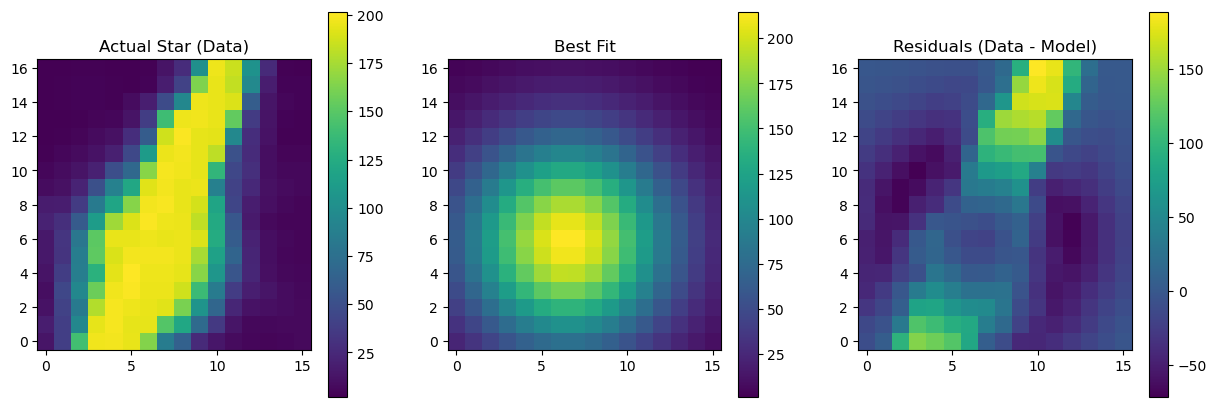

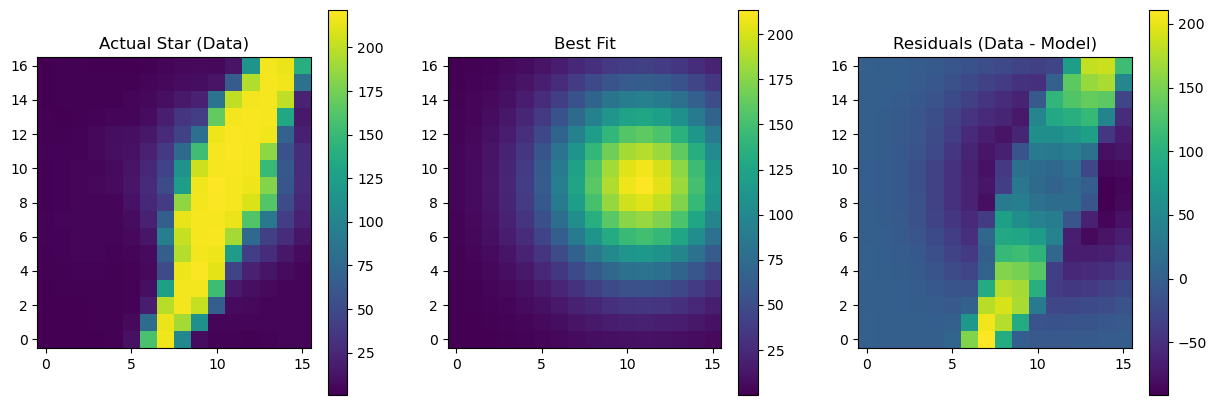

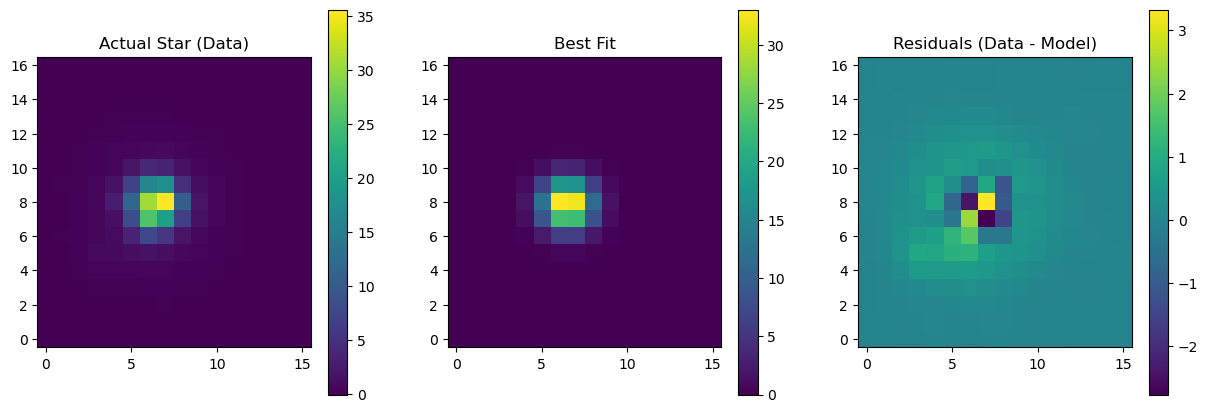

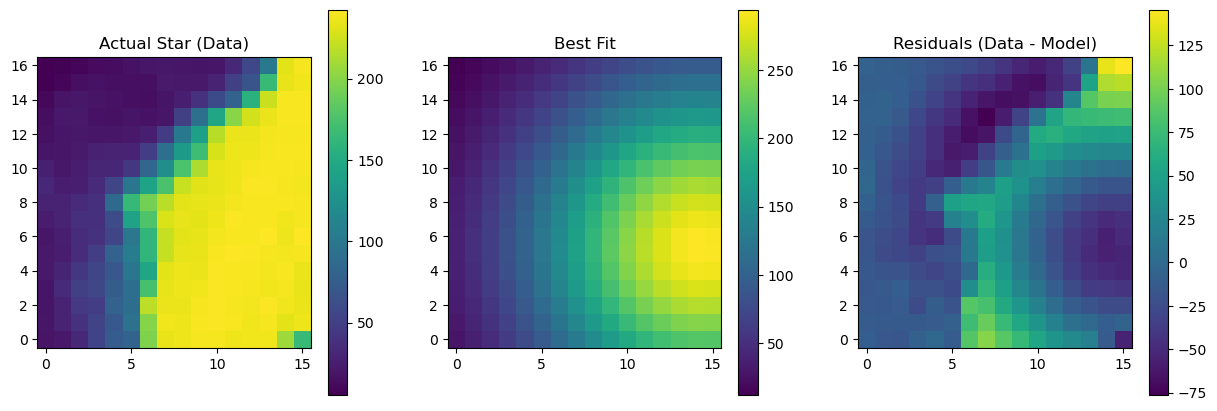

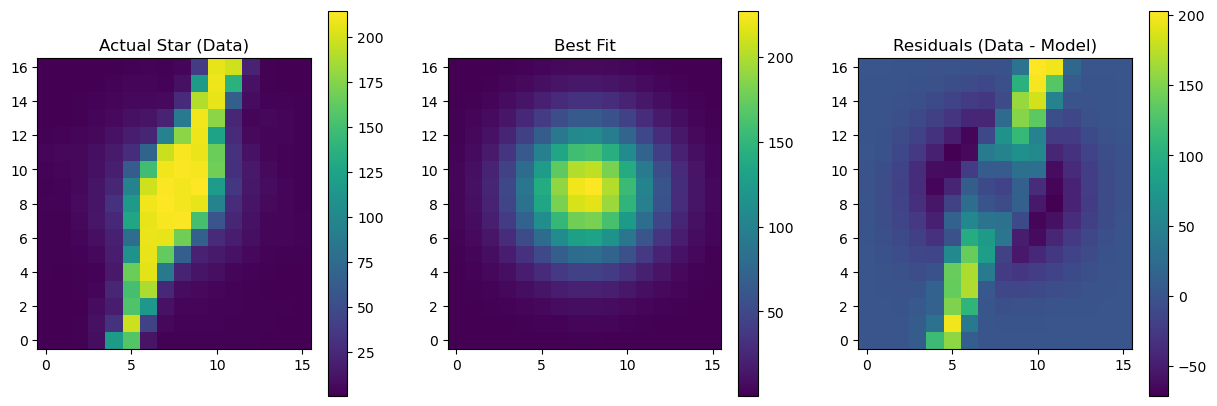

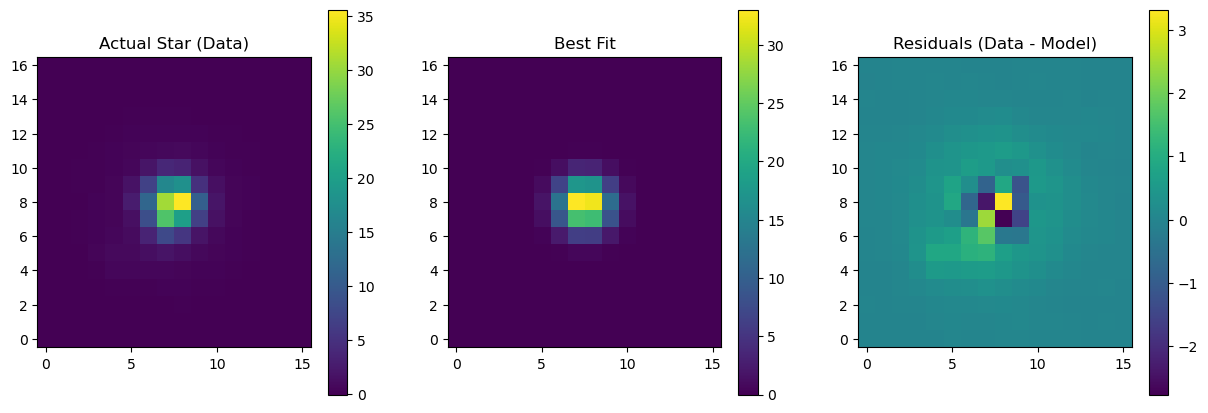

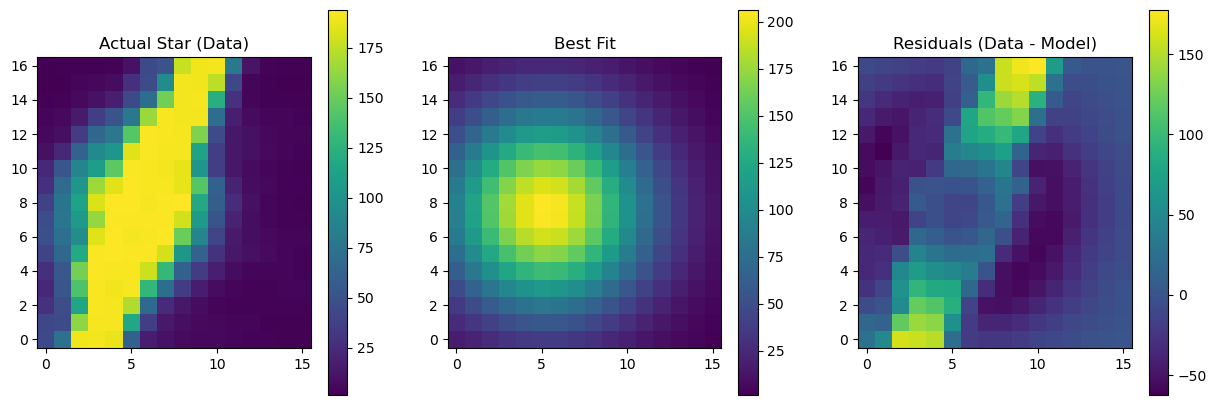

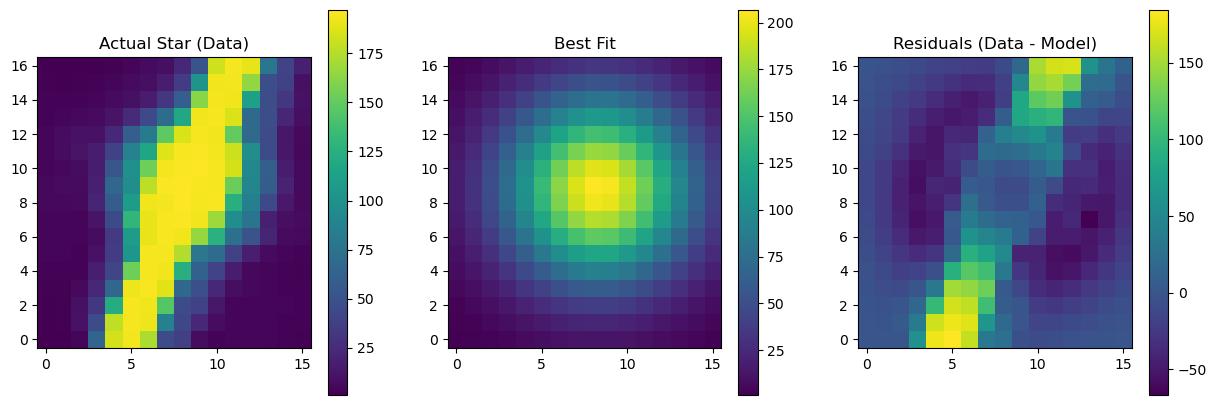

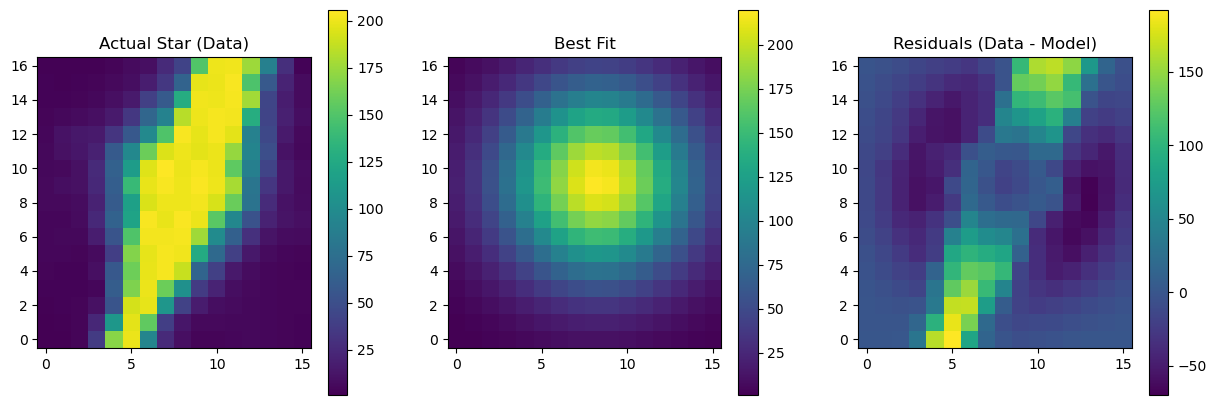

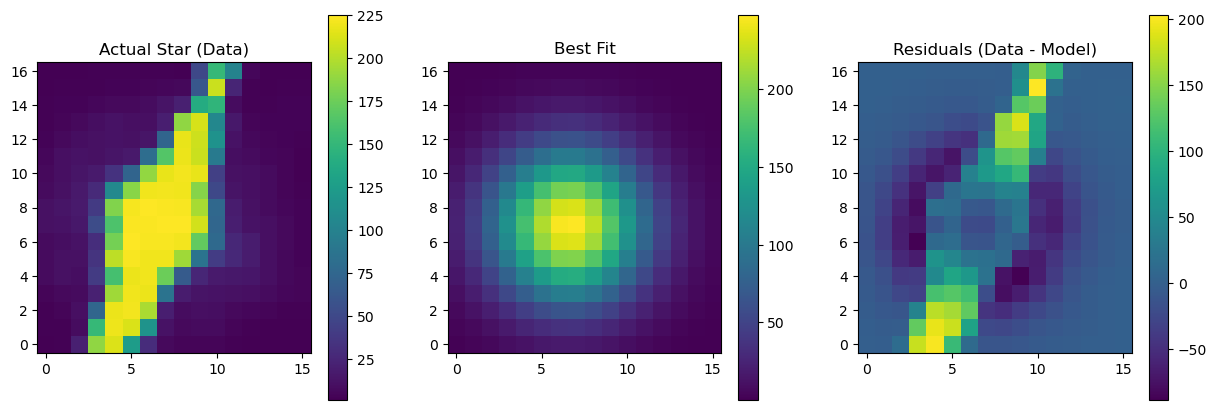

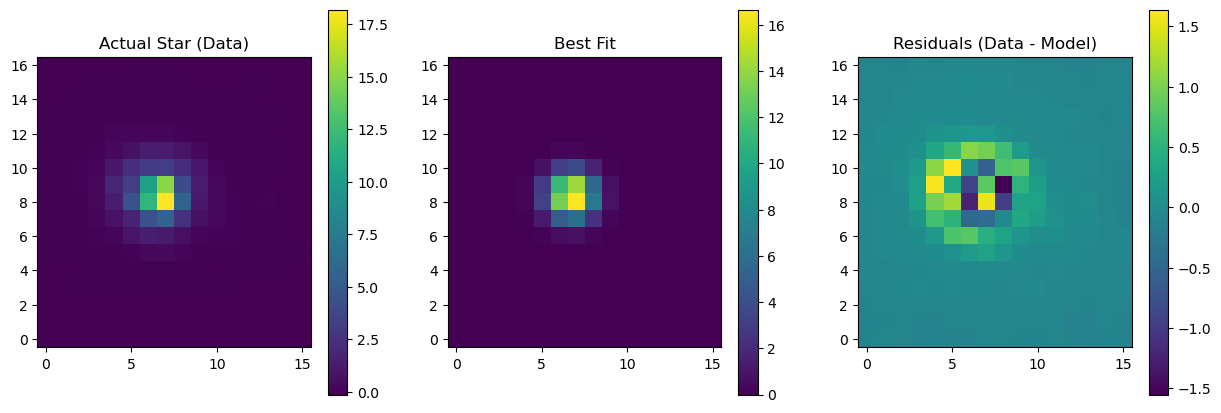

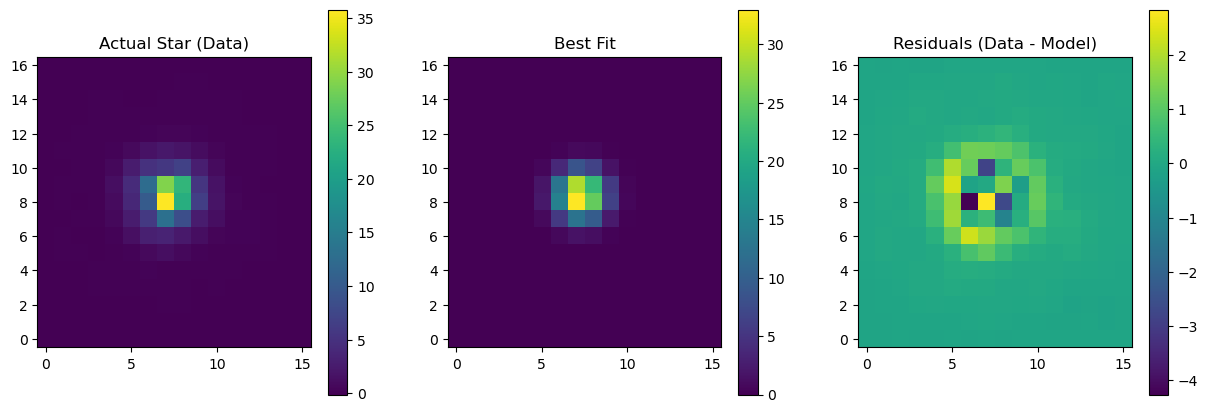

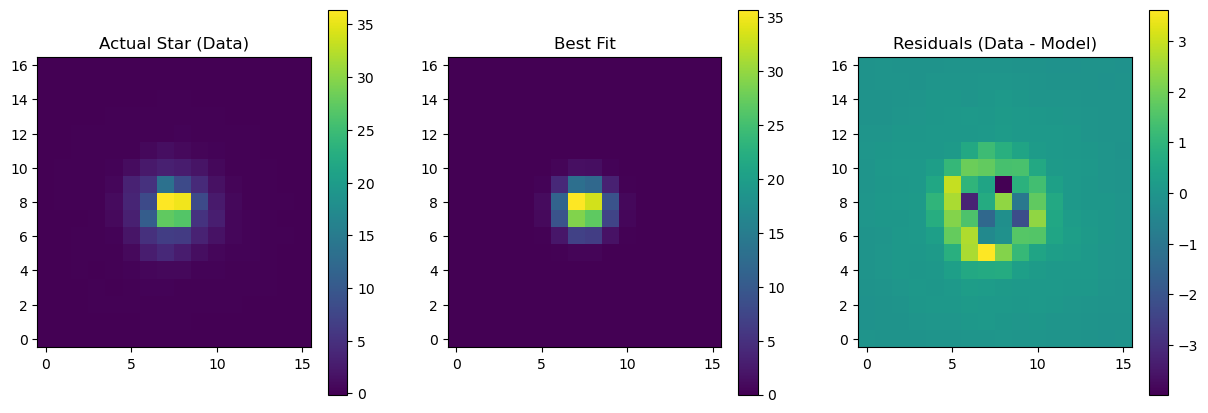

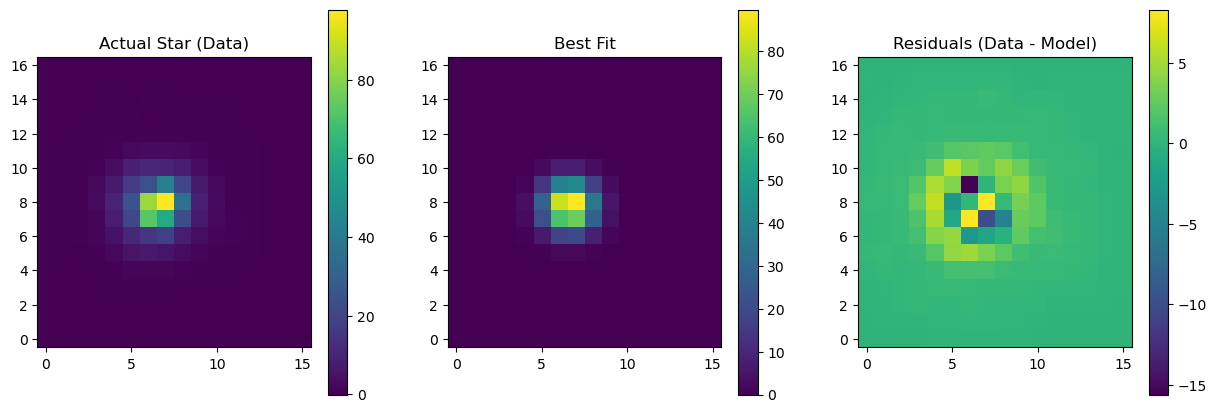

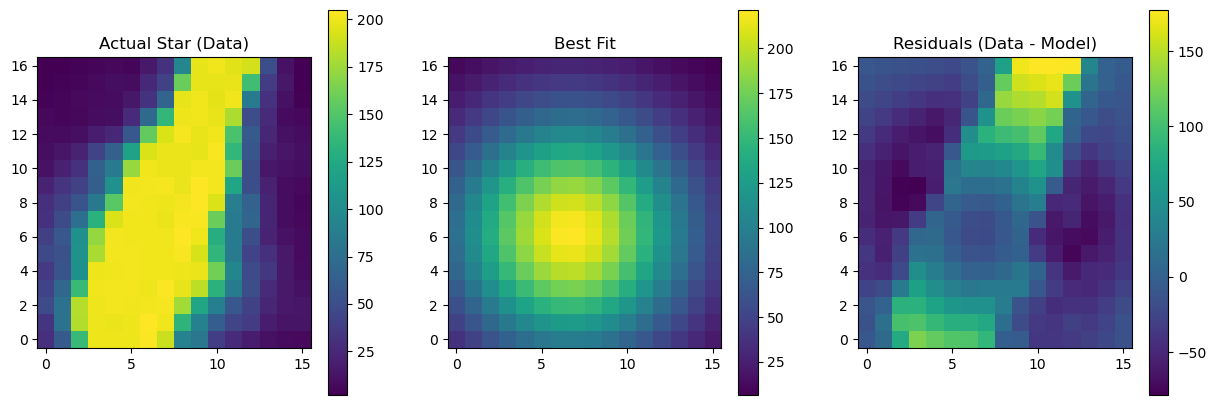

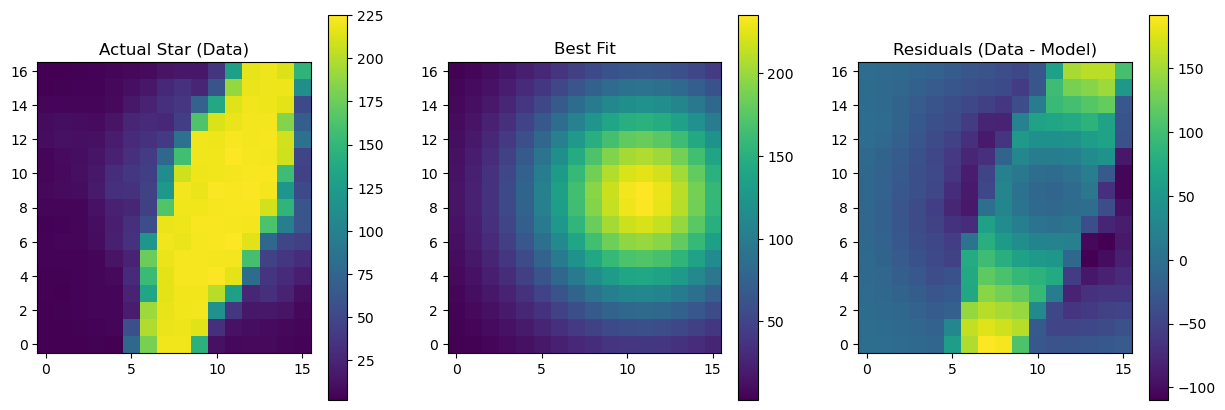

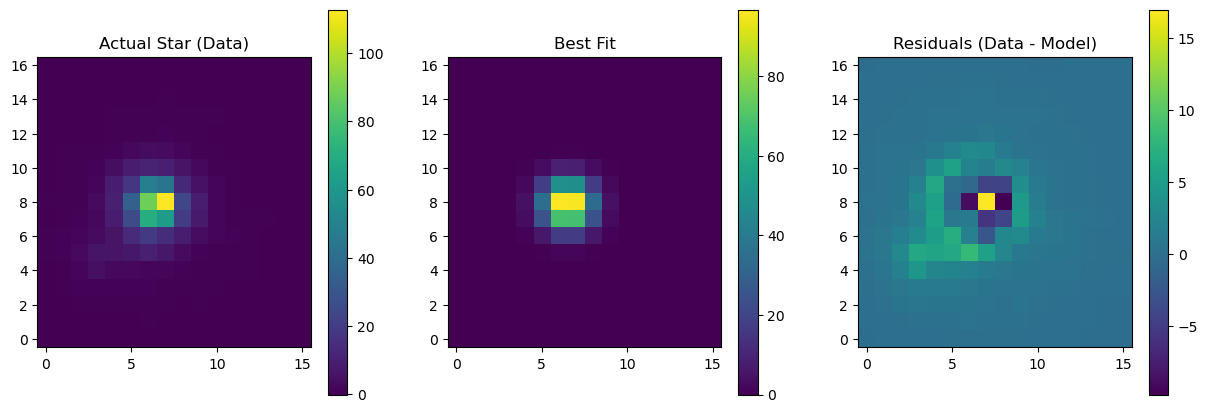

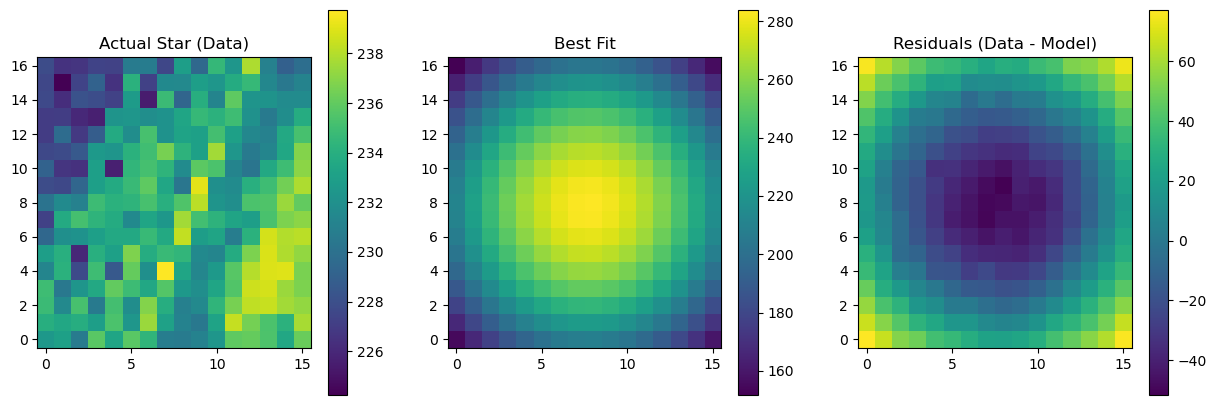

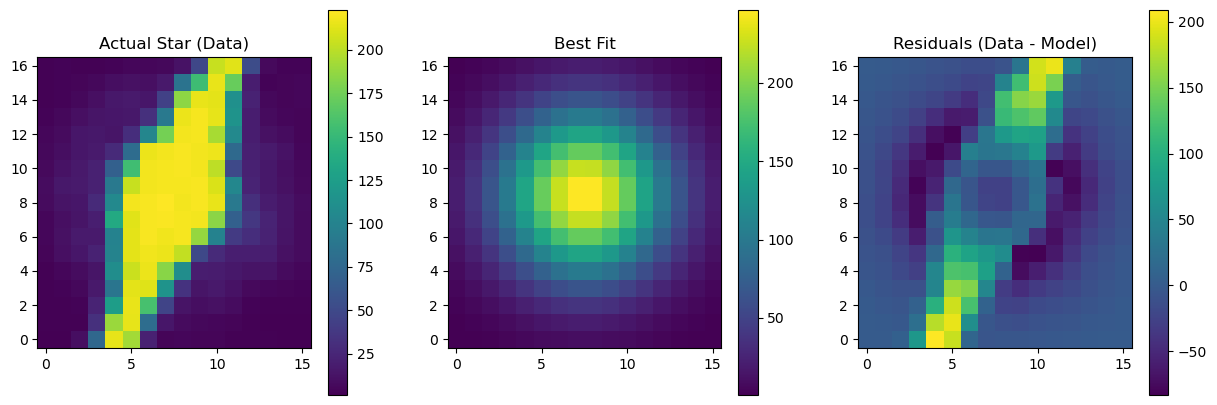

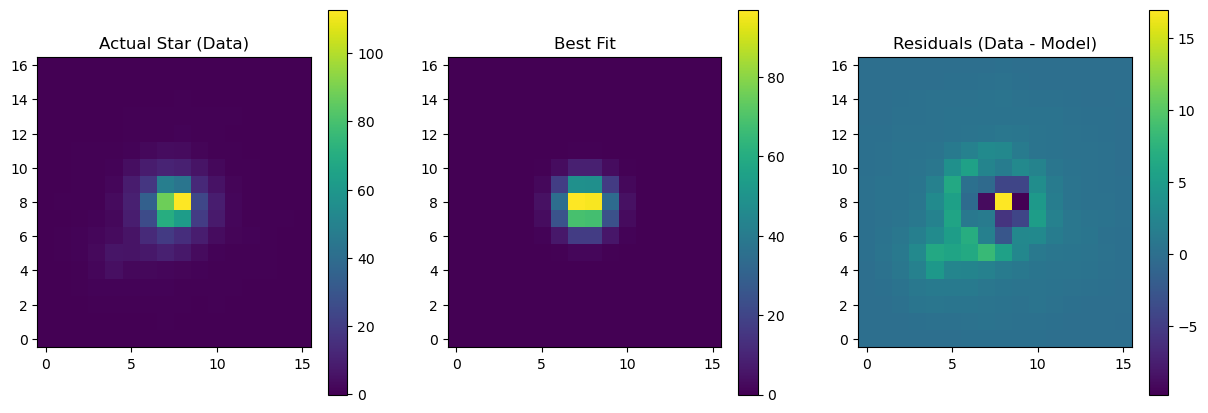

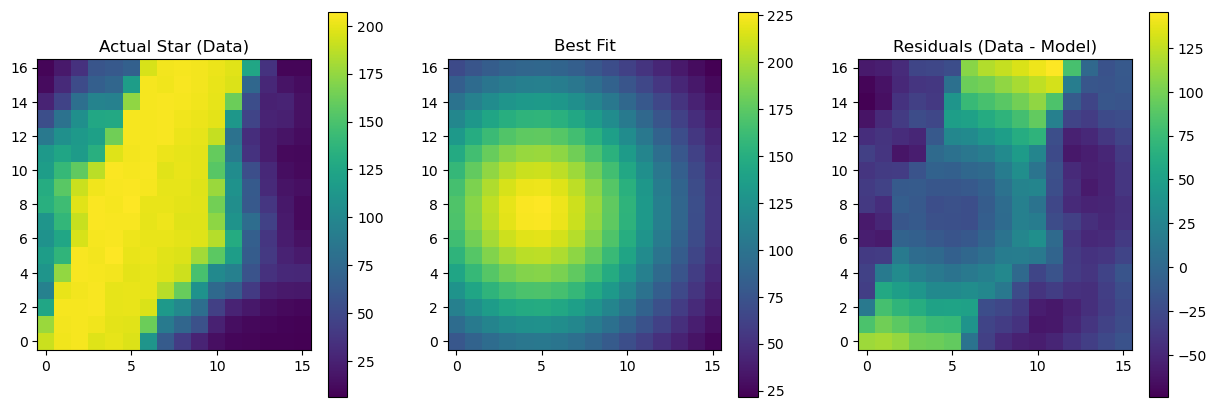

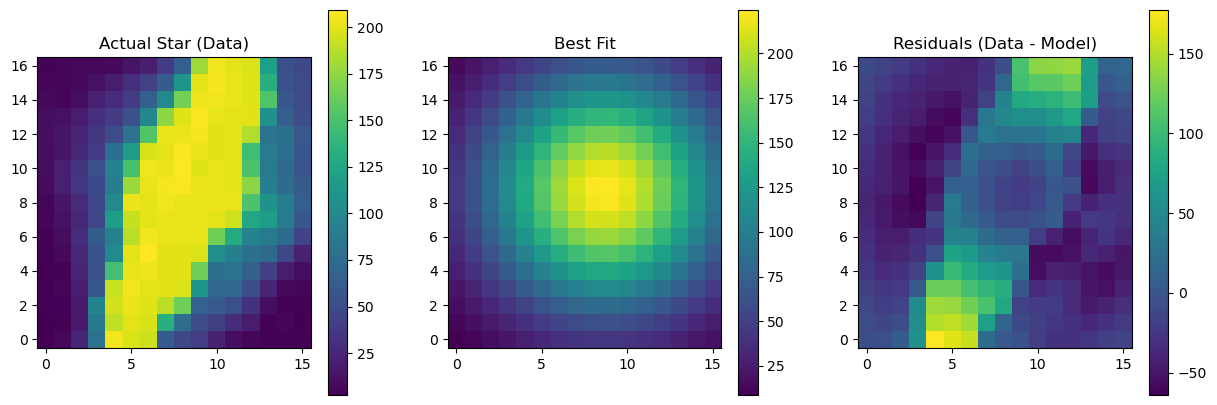

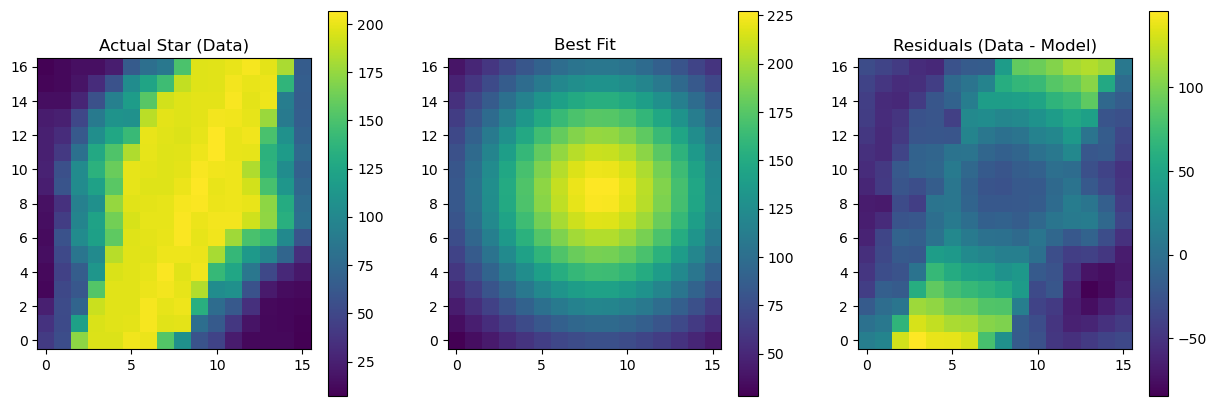

In [266]:


def psf_fit(coords, row, col, sigma=3, amplitude_func=100, offset=0):
    x, y = coords
    

    psf = amplitude_func * np.exp(-((y-row)**2 + (x-col)**2)/(2*sigma**2))
    fwhm = 2.355*sigma
    return psf.ravel()

def image_2660(selected_image):
    for s in stars:
        cutout = s.cutout(image=selected_image)
        y_size, x_size = cutout.shape
        yy, xx = np.meshgrid(np.arange(y_size), np.arange(x_size), indexing='ij') 
        xdata = (yy, xx)
        ydata = cutout.ravel()
        print(ydata.shape)
        ydata = np.nan_to_num(ydata, nan=np.nanmedian(ydata))
        peak = np.max(ydata)
        bg = np.median(ydata)

        lower_bounds = [0, 0, 0.5, 0, -np.inf]
        upper_bounds = [y_size, x_size, 10.0, np.inf, np.inf]
        
        p0 = [
        y_size / 2,
        x_size / 2,
        1.0,
        peak - bg,
        bg
        ]
        print(p0)
        popt, pcov = optimize.curve_fit(
            psf_fit,
            xdata,
            ydata,
            p0=p0,
            bounds=(lower_bounds, upper_bounds),
            maxfev=2000
        )
        fit_model = psf_fit(xdata, *popt).reshape(y_size, x_size)
        actual_data = ydata.reshape(y_size, x_size)
        fig, ax = plt.subplots(1, 3, figsize=(15, 5))

        im0 = ax[0].imshow(actual_data, origin='lower')
        ax[0].set_title('Actual Star (Data)')
        fig.colorbar(im0, ax=ax[0])
        
        im1 = ax[1].imshow(fit_model, origin='lower')
        ax[1].set_title('Best Fit')
        fig.colorbar(im1, ax=ax[1])
        
        im2 = ax[2].imshow(actual_data - fit_model, origin='lower')
        ax[2].set_title('Residuals (Data - Model)')
        fig.colorbar(im2, ax=ax[2]) 
        print(f"popt {popt}")
image_2660(subtracted_image_555)
image_2660(subtracted_image_814)